# Crypto Gravity Model
### MS996 | Management Science Project
#### Nicholas Ballingall | March 2026

This is a modified version of the Walker Gravity Model designed to measure global Cryptocurrency laundering

## Notebook Setup

In [1]:
# --- Import Libraries ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pycountry

# --- Output Formatting ---
ind = '   ' # 3-space indent

In [2]:
# --- Import Data ---

local_path = '/Users/nickballingall/Library/CloudStorage/OneDrive-UniversityofStrathclyde/MSc FInTech/Uni Projects/Management Science/Data/gdp_data'

gdp_raw = pd.read_csv(f'{local_path}/gdp.csv')
gdp_raw = gdp_raw[['Country Name', '2020']]
gdp_raw = gdp_raw.rename(columns={'Country Name': 'country_name', '2020': 'gdp'})

geo_dist = pd.read_excel(f'{local_path}/dist_cepii.xls')

crime_data = pd.read_csv(f'{local_path}/crime_data.csv')

crypto_adoption = pd.read_excel(f'{local_path}/crypto_adoption_index.xlsx')

black_list = ["Democratic People's Republic of Korea", "Iran", "Myanmar"] # apostraphe in korea
grey_list = [
    "Algeria",
    "Angola",
    "Bolivia",
    "Bulgaria",
    "Cameroon",
    "Côte d'Ivoire",
    "Democratic Republic of Congo",
    "Haiti",
    "Kenya",
    "Kuwait",
    "Lao People's Democratic Republic",
    "Lebanon",
    "Monaco",
    "Namibia",
    "Nepal",
    "Papua New Guinea",
    "South Sudan",
    "Syria",
    "Venezuela",
    "Vietnam",
    "Virgin Islands (UK)",
    "Yemen"
]

### Data Sources

**GDP Raw:** https://www.kaggle.com/datasets/zgrcemta/world-gdpgdp-gdp-per-capita-and-annual-growths  
**Geo Dist:** https://www.cepii.fr/cepii/en/bdd_modele/bdd_modele_item.asp?id=6  
**Crime Data:** https://www.kaggle.com/datasets/shahriarkabir/crime-rate-by-country-2024  
**Crypto Adoption:** https://www.chainalysis.com/blog/2025-global-crypto-adoption-index/  
**Black & Grey Lists:** https://www.fatf-gafi.org/en/countries/black-and-grey-lists.html

## Model Feature Engineering

In [5]:
# --- Map Country Strings to ISO Code ---

def get_iso_code(country_name):
    try:
        return pycountry.countries.search_fuzzy(country_name)[0].alpha_3
    except LookupError:
        return None

# Apply to DFs
gdp_raw['iso_code'] = gdp_raw['country_name'].apply(get_iso_code)
crime_data['iso_code'] = crime_data['country'].apply(get_iso_code)


# Merge Data 1
countries_df = pd.merge(
    gdp_raw, 
    crime_data[['iso_code', 'CrimeRate_OverallCriminalityScoreGOCI']], 
    on='iso_code', 
    how='left'
)

# shorten crime score name
countries_df = countries_df.rename(columns={'CrimeRate_OverallCriminalityScoreGOCI': 'goci_criminality_score'})

# Fill missing crime scores with a global median to prevent math errors
median_crime = countries_df['goci_criminality_score'].median()
countries_df['goci_criminality_score'] = countries_df['goci_criminality_score'].fillna(median_crime)
countries_df.dropna(inplace=True)

In [6]:
# --- Prepare Origin Mass & Attractiveness ---

# Create Attractiveness Score
"""
Inverts the rank in the Chainalysis Index (max 131).
"""
max_rank = crypto_adoption['Overall index ranking'].max()
crypto_adoption['empirical_attractiveness'] = (max_rank + 1) - crypto_adoption['Overall index ranking']

# Merge 2
countries_df = pd.merge(
    countries_df, 
    crypto_adoption[['Country', 'empirical_attractiveness']], 
    left_on='country_name', 
    right_on='Country', 
    how='left'
)

# Set baseline attrativeness of 1 for missing countries
countries_df['empirical_attractiveness'] = countries_df['empirical_attractiveness'].fillna(1)

# Extract valid ISO codes
valid_isos = countries_df['iso_code'].dropna().unique().tolist()

# Origin Mass (M_i): GDP weighted by GOCI Criminality (aka illicit mass)
countries_df['crime_multiplier'] = countries_df['goci_criminality_score'] / 10.0
countries_df['illicit_mass'] = countries_df['gdp'] * countries_df['crime_multiplier']
mass = dict(zip(countries_df['iso_code'], countries_df['illicit_mass']))

# 1b. Destination Attractiveness (A_j): Chainalysis Rank
attractiveness = dict(zip(countries_df['iso_code'], countries_df['empirical_attractiveness']))

In [7]:
# --- Build Virtual Friction Matrix (F_ij) ---

# Baseline Friction
geo_dist['virtual_friction'] = 10.0 # high for cross-border criminal coordination

# Friction Reducers
geo_dist.loc[geo_dist['comlang_off'] == 1, 'virtual_friction'] -= 4.0 # shared official language
geo_dist.loc[geo_dist['colony'] == 1, 'virtual_friction'] -= 3.0      # historical banking/colonial ties
geo_dist.loc[geo_dist['contig'] == 1, 'virtual_friction'] -= 2.0      # shared physical border 

# Prevent fiction from dropping below 1 (aoids 'infinite gractity'/ division by 0)
geo_dist['virtual_friction'] = geo_dist['virtual_friction'].clip(lower=1.0)

# Pivot into Square Matrix
friction_matrix = geo_dist.pivot(index='iso_o', columns='iso_d', values='virtual_friction')

# Fill Missing Pairs with Baseline Friction
friction_matrix = friction_matrix.reindex(index=valid_isos, columns=valid_isos).fillna(10.0)

# Beta: how strictly virtual friction deters the flow
beta = 2.0

## Construct Model

In [9]:
# --- Core Crypto Gravity Model ---

def calculate_crypto_gravity(countries, M, A, F, beta):
    flow_matrix = pd.DataFrame(index=countries, columns=countries, dtype=float)
    
    for origin in countries:
        for destination in countries:
            if origin == destination:
                flow_matrix.loc[origin, destination] = 0.0 # no self-flow
            else:
                # Handle missing data
                m_i = M.get(origin, 0)
                a_j = A.get(destination, 0)
                f_ij = F.loc[origin, destination]
                
                # The Crypto Gravity Formula
                flow = (m_i * a_j) / (f_ij ** beta)
                flow_matrix.loc[origin, destination] = flow
                
    return flow_matrix

print(f"{ind}> Calculating Crypto Laundering Flows")
crypto_flow_matrix = calculate_crypto_gravity(valid_isos, mass, attractiveness, friction_matrix, beta)
print(f"{ind}> Calculation Complete")

   > Calculating Crypto Laundering Flows
   > Calculation Complete



--- Top 10 Crypto Laundering Flows (Virtual Friction) ---



,Origin,Destination,Flow
1,USA,PHL,"161,044,988,579,999.97"
2,USA,GBR,"158,404,906,799,999.97"
3,RUS,KAZ,"77,456,386,343,507.14"
4,USA,CAN,"77,222,392,064,999.98"
5,GBR,IRL,"63,475,493,422,252.59"
6,USA,IND,"42,901,328,924,999.99"
7,USA,PAK,"42,241,308,479,999.99"
8,USA,NGA,"41,251,277,812,499.99"
9,USA,ETH,"39,271,216,477,499.99"
10,USA,KEN,"34,981,083,584,999.99"


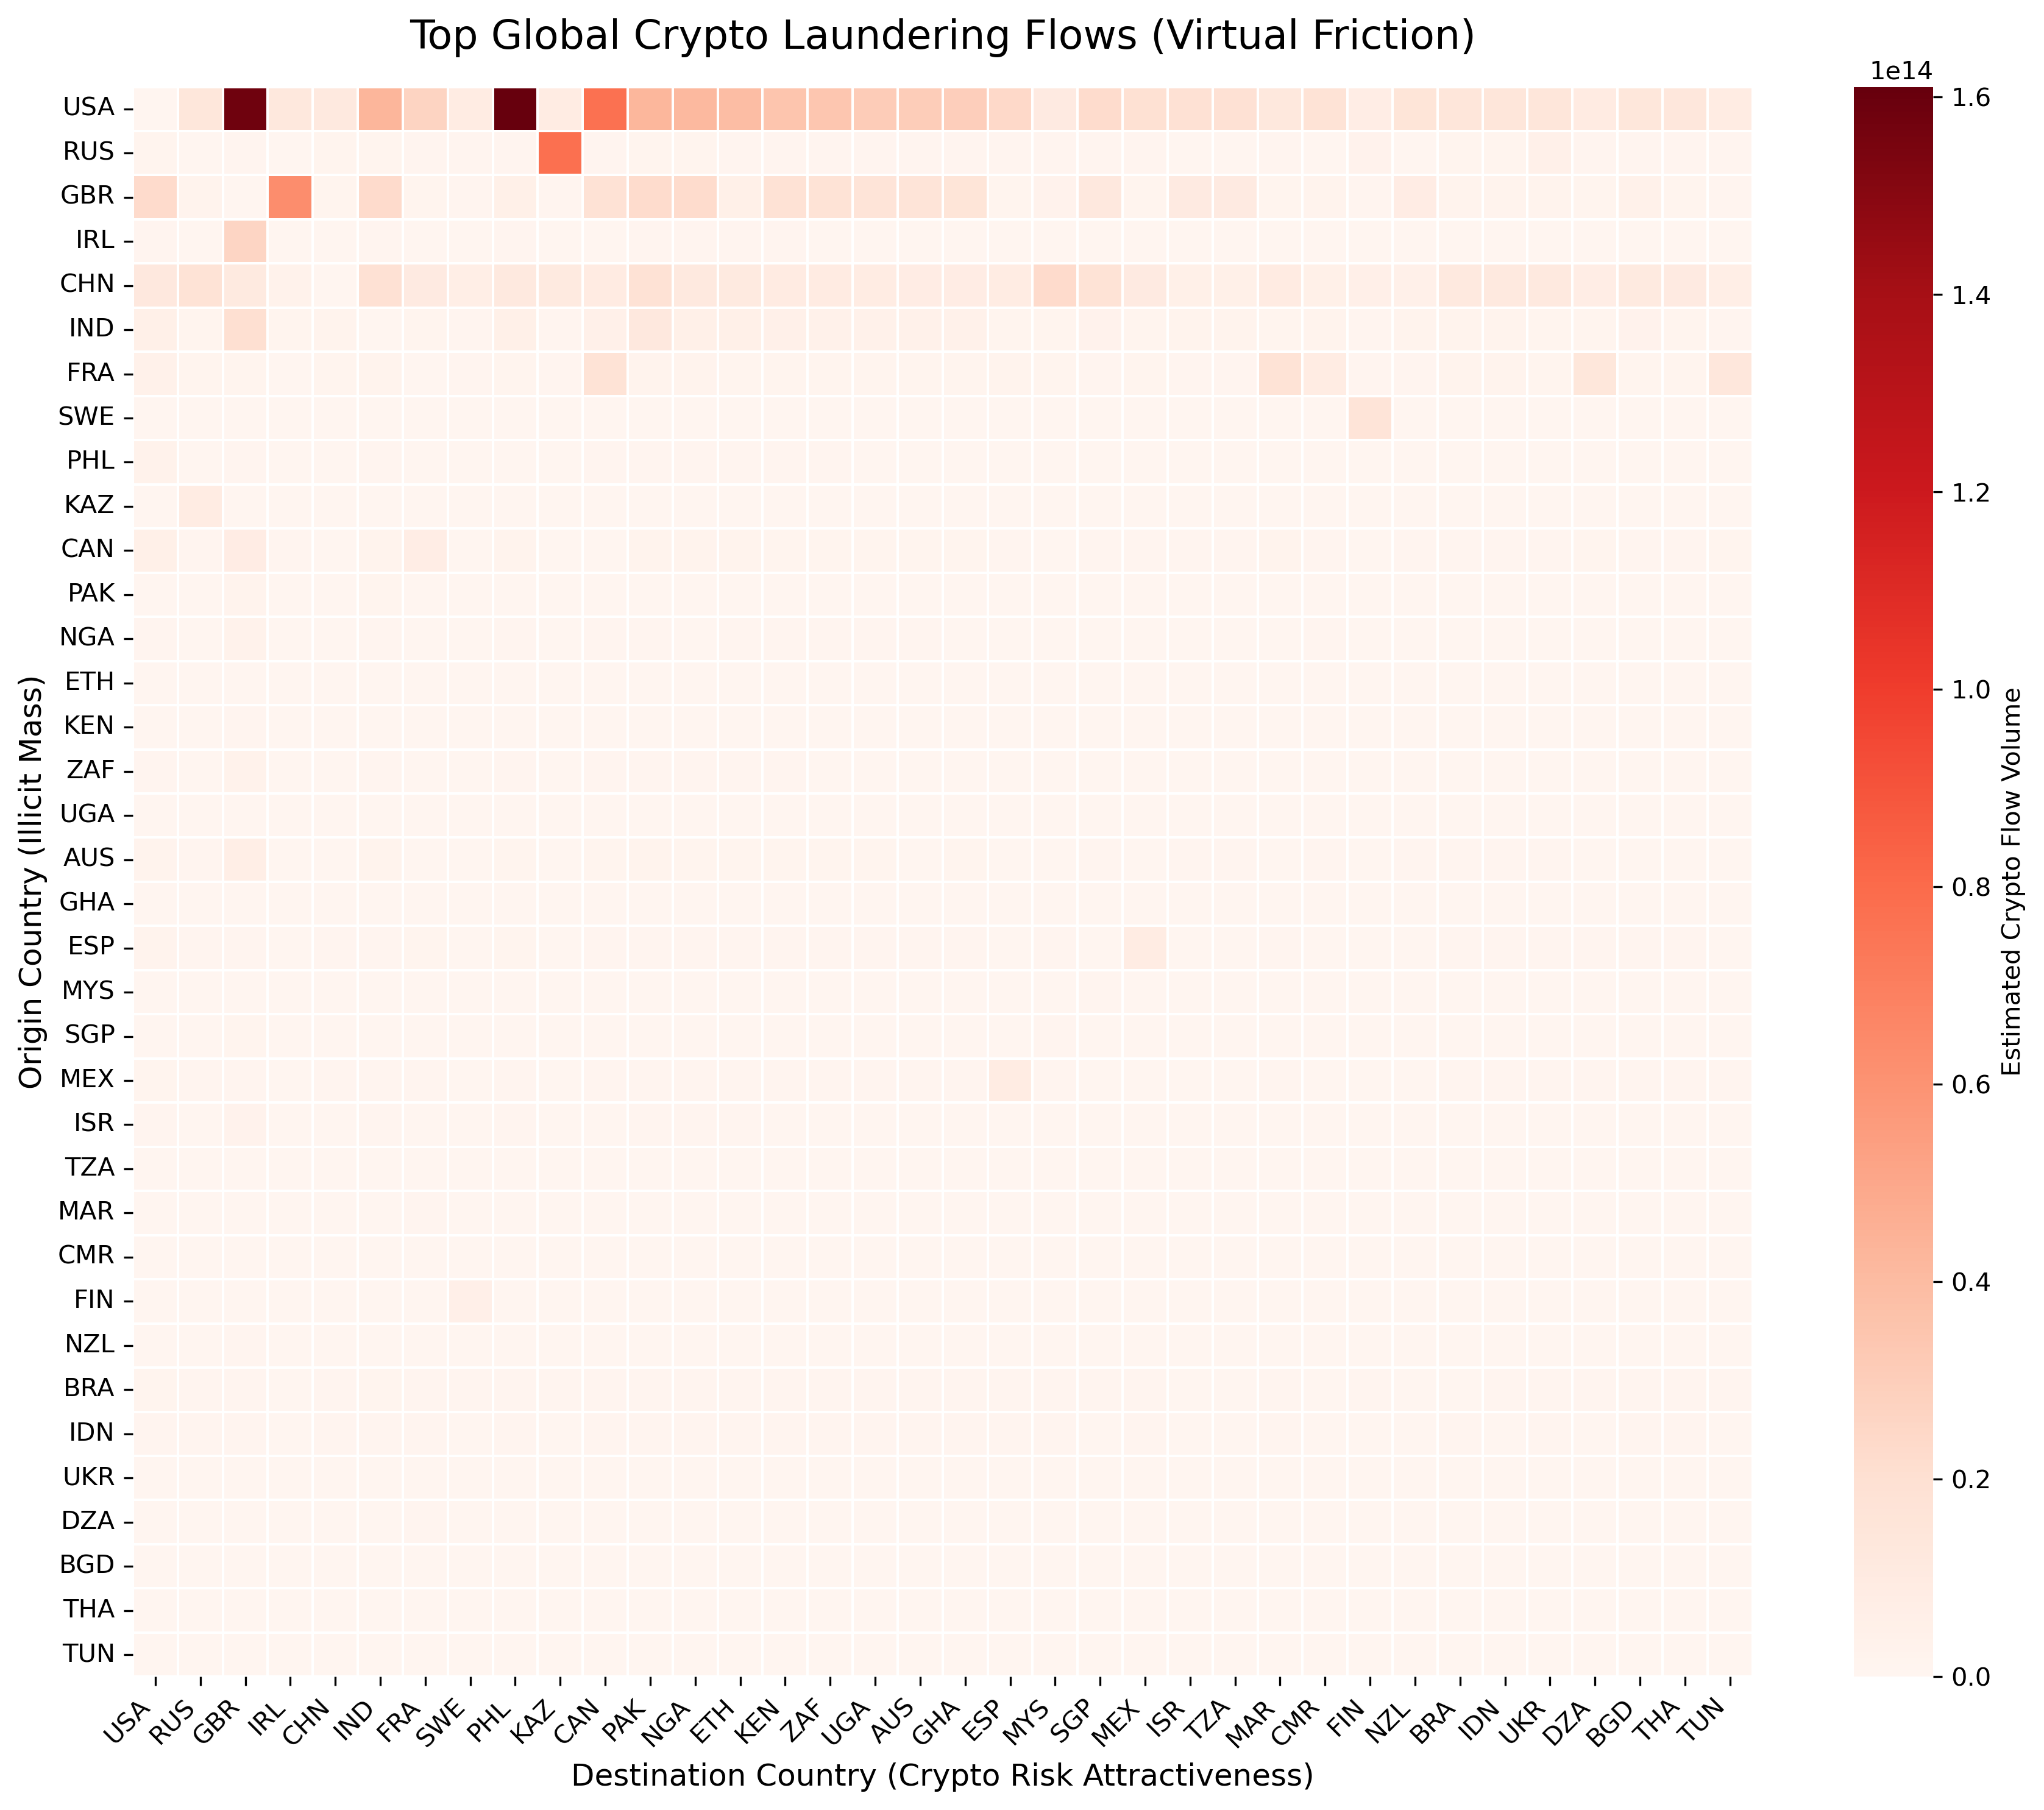

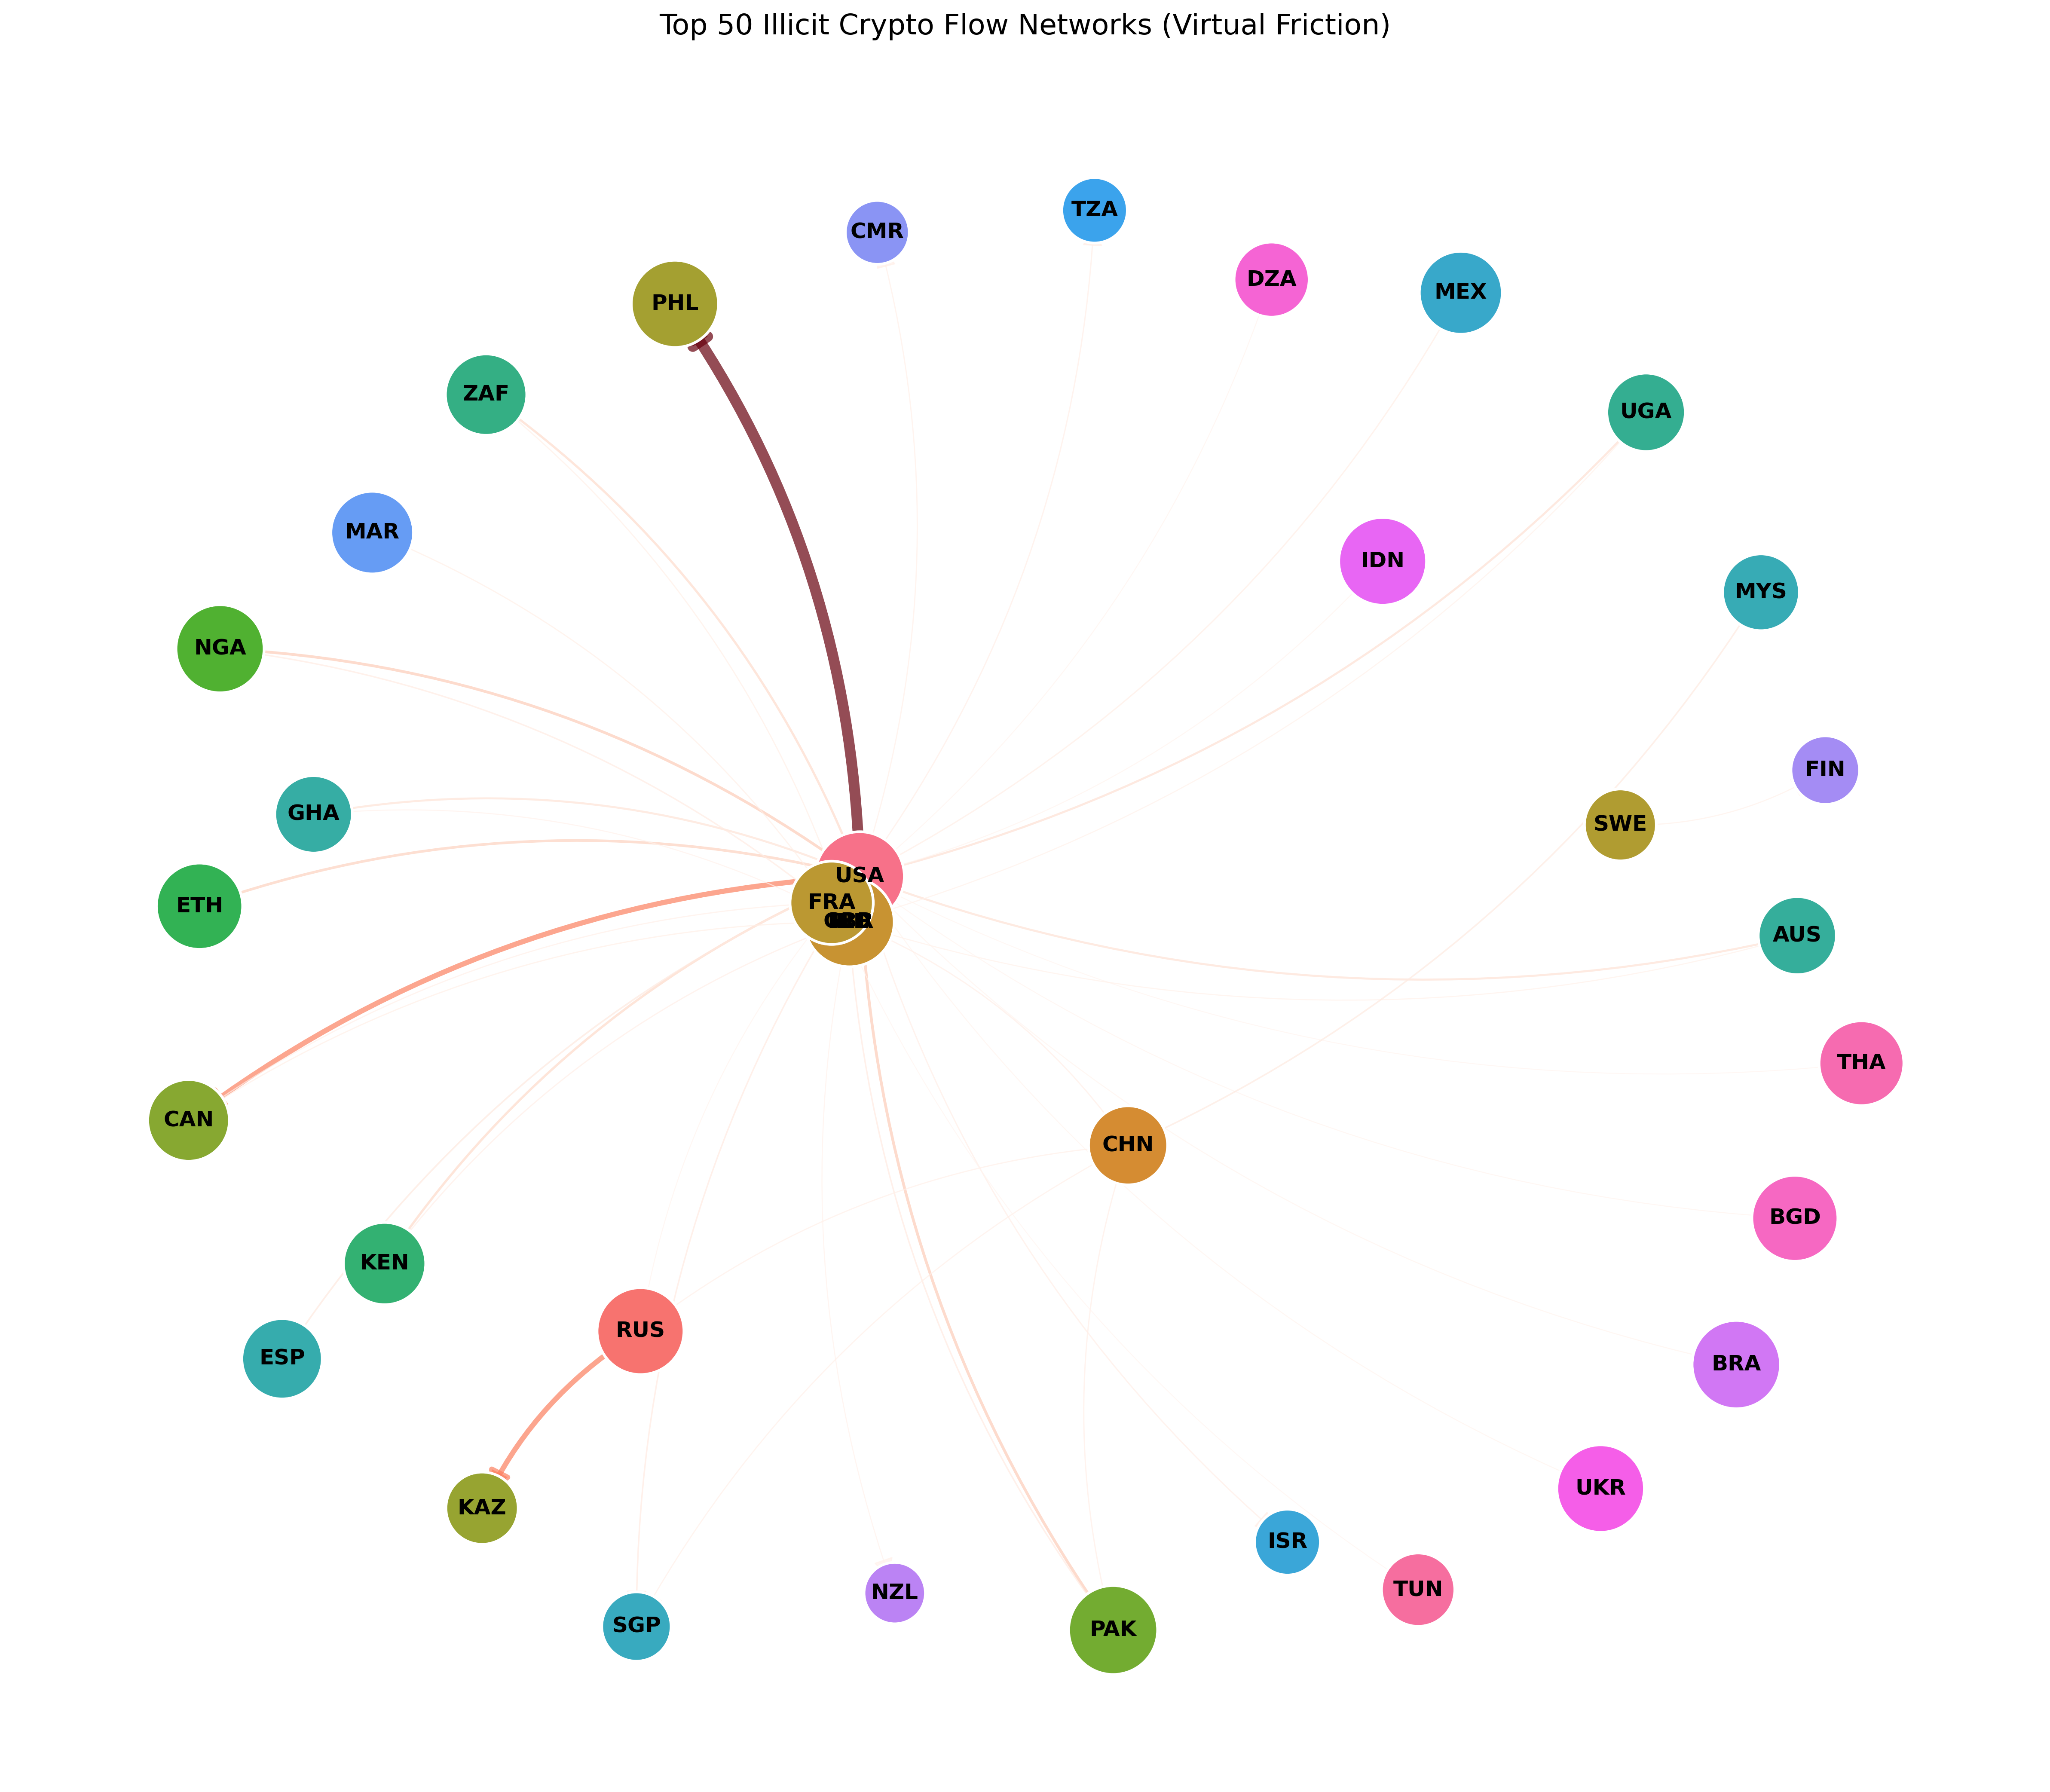

In [48]:
# --- Filter for Top Flows ---

num_top_flows = 50
num_print_flows = 10

# Flatten & Sort Matrix
stacked_flows = crypto_flow_matrix.stack().reset_index()
stacked_flows.columns = ['Origin', 'Destination', 'Flow']
top_flows = stacked_flows.sort_values(by='Flow', ascending=False).head(num_top_flows)

# Format
summary_df = top_flows.copy()
summary_df['Flow'] = summary_df['Flow'].map('{:,.2f}'.format)
summary_df.index = np.arange(1, len(summary_df) + 1)

# Display
print(f"\n--- Top {num_print_flows} Crypto Laundering Flows (Virtual Friction) ---\n")
display(summary_df.head(num_print_flows))

# --- Visualisations ---

top_countries = pd.concat([top_flows['Origin'], top_flows['Destination']]).unique().tolist()
top_matrix = crypto_flow_matrix.loc[top_countries, top_countries]

# Plot 1: Flow Matrix Heatmap
plt.figure(figsize=(12, 10), dpi=300)
sns.heatmap(top_matrix,
            annot=False,
            cmap="Reds", 
            linewidths=0.5,
            cbar_kws={'label': 'Estimated Crypto Flow Volume'})

plt.title('Top Global Crypto Laundering Flows (Virtual Friction)', fontsize=16, pad=15)
plt.ylabel('Origin Country (Illicit Mass)', fontsize=12)
plt.xlabel('Destination Country (Crypto Risk Attractiveness)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 2: Directed Network Graph
plt.figure(figsize=(16, 14), dpi=300)
G = nx.DiGraph()

# Add Top Country Nodes
for c in top_countries:
    G.add_node(c, mass=mass.get(c, 0), attr=attractiveness.get(c, 0))

# Add Top Flows Edges
for _, row in top_flows.iterrows():
    G.add_edge(row['Origin'], row['Destination'], weight=row['Flow'])

# Graph Layout (higher k to push nodes apart)
pos = nx.spring_layout(G, k=2.5, seed=27)

# Normalise Node Sizes
raw_attrs = [attractiveness.get(node, 1) for node in G.nodes()]
max_attr = max(raw_attrs) if raw_attrs else 1

# Scale sizes proportionally (400 min - 2500 max)
node_sizes = [400 + (attr / max_attr) * 2100 for attr in raw_attrs]

# Distinct Node Colours
num_nodes = len(G.nodes())
node_colors = sns.color_palette("husl", num_nodes)

# Draw Nodes (size based on attractiveness score)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, edgecolors='white', linewidths=1.5)

# Draw Edges (thickness based on flow volume)
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
max_weight = max(weights) if weights else 1
normalised_weights = [(w / max_weight) * 6 for w in weights]

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=edges,
    width=normalised_weights,
    edge_color=weights,
    edge_cmap=plt.cm.Reds,
    arrows=True,
    arrowsize=25, 
    connectionstyle="arc3,rad=0.15",
    alpha=0.7
)

nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

plt.title(f'Top {num_top_flows} Illicit Crypto Flow Networks (Virtual Friction)', fontsize=16, pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()